In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(data.head())
data.info()
print(data.describe())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print("Missing values before handling:")
print(data.isnull().sum())

Missing values before handling:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


The **TotalCharges** column is currently
stored as an object (string) rather than a numeric value,
so it needs to be converted to a numeric type before performing any calculations or analysis.


In [4]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
print("\nMissing values after converting TotalCharges:")
print(data.isnull().sum())


Missing values after converting TotalCharges:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [5]:
data.dropna(inplace=True) # Dropping rows with missing values
print("\nMissing values after dropping rows:")
print(data.isnull().sum())


Missing values after dropping rows:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


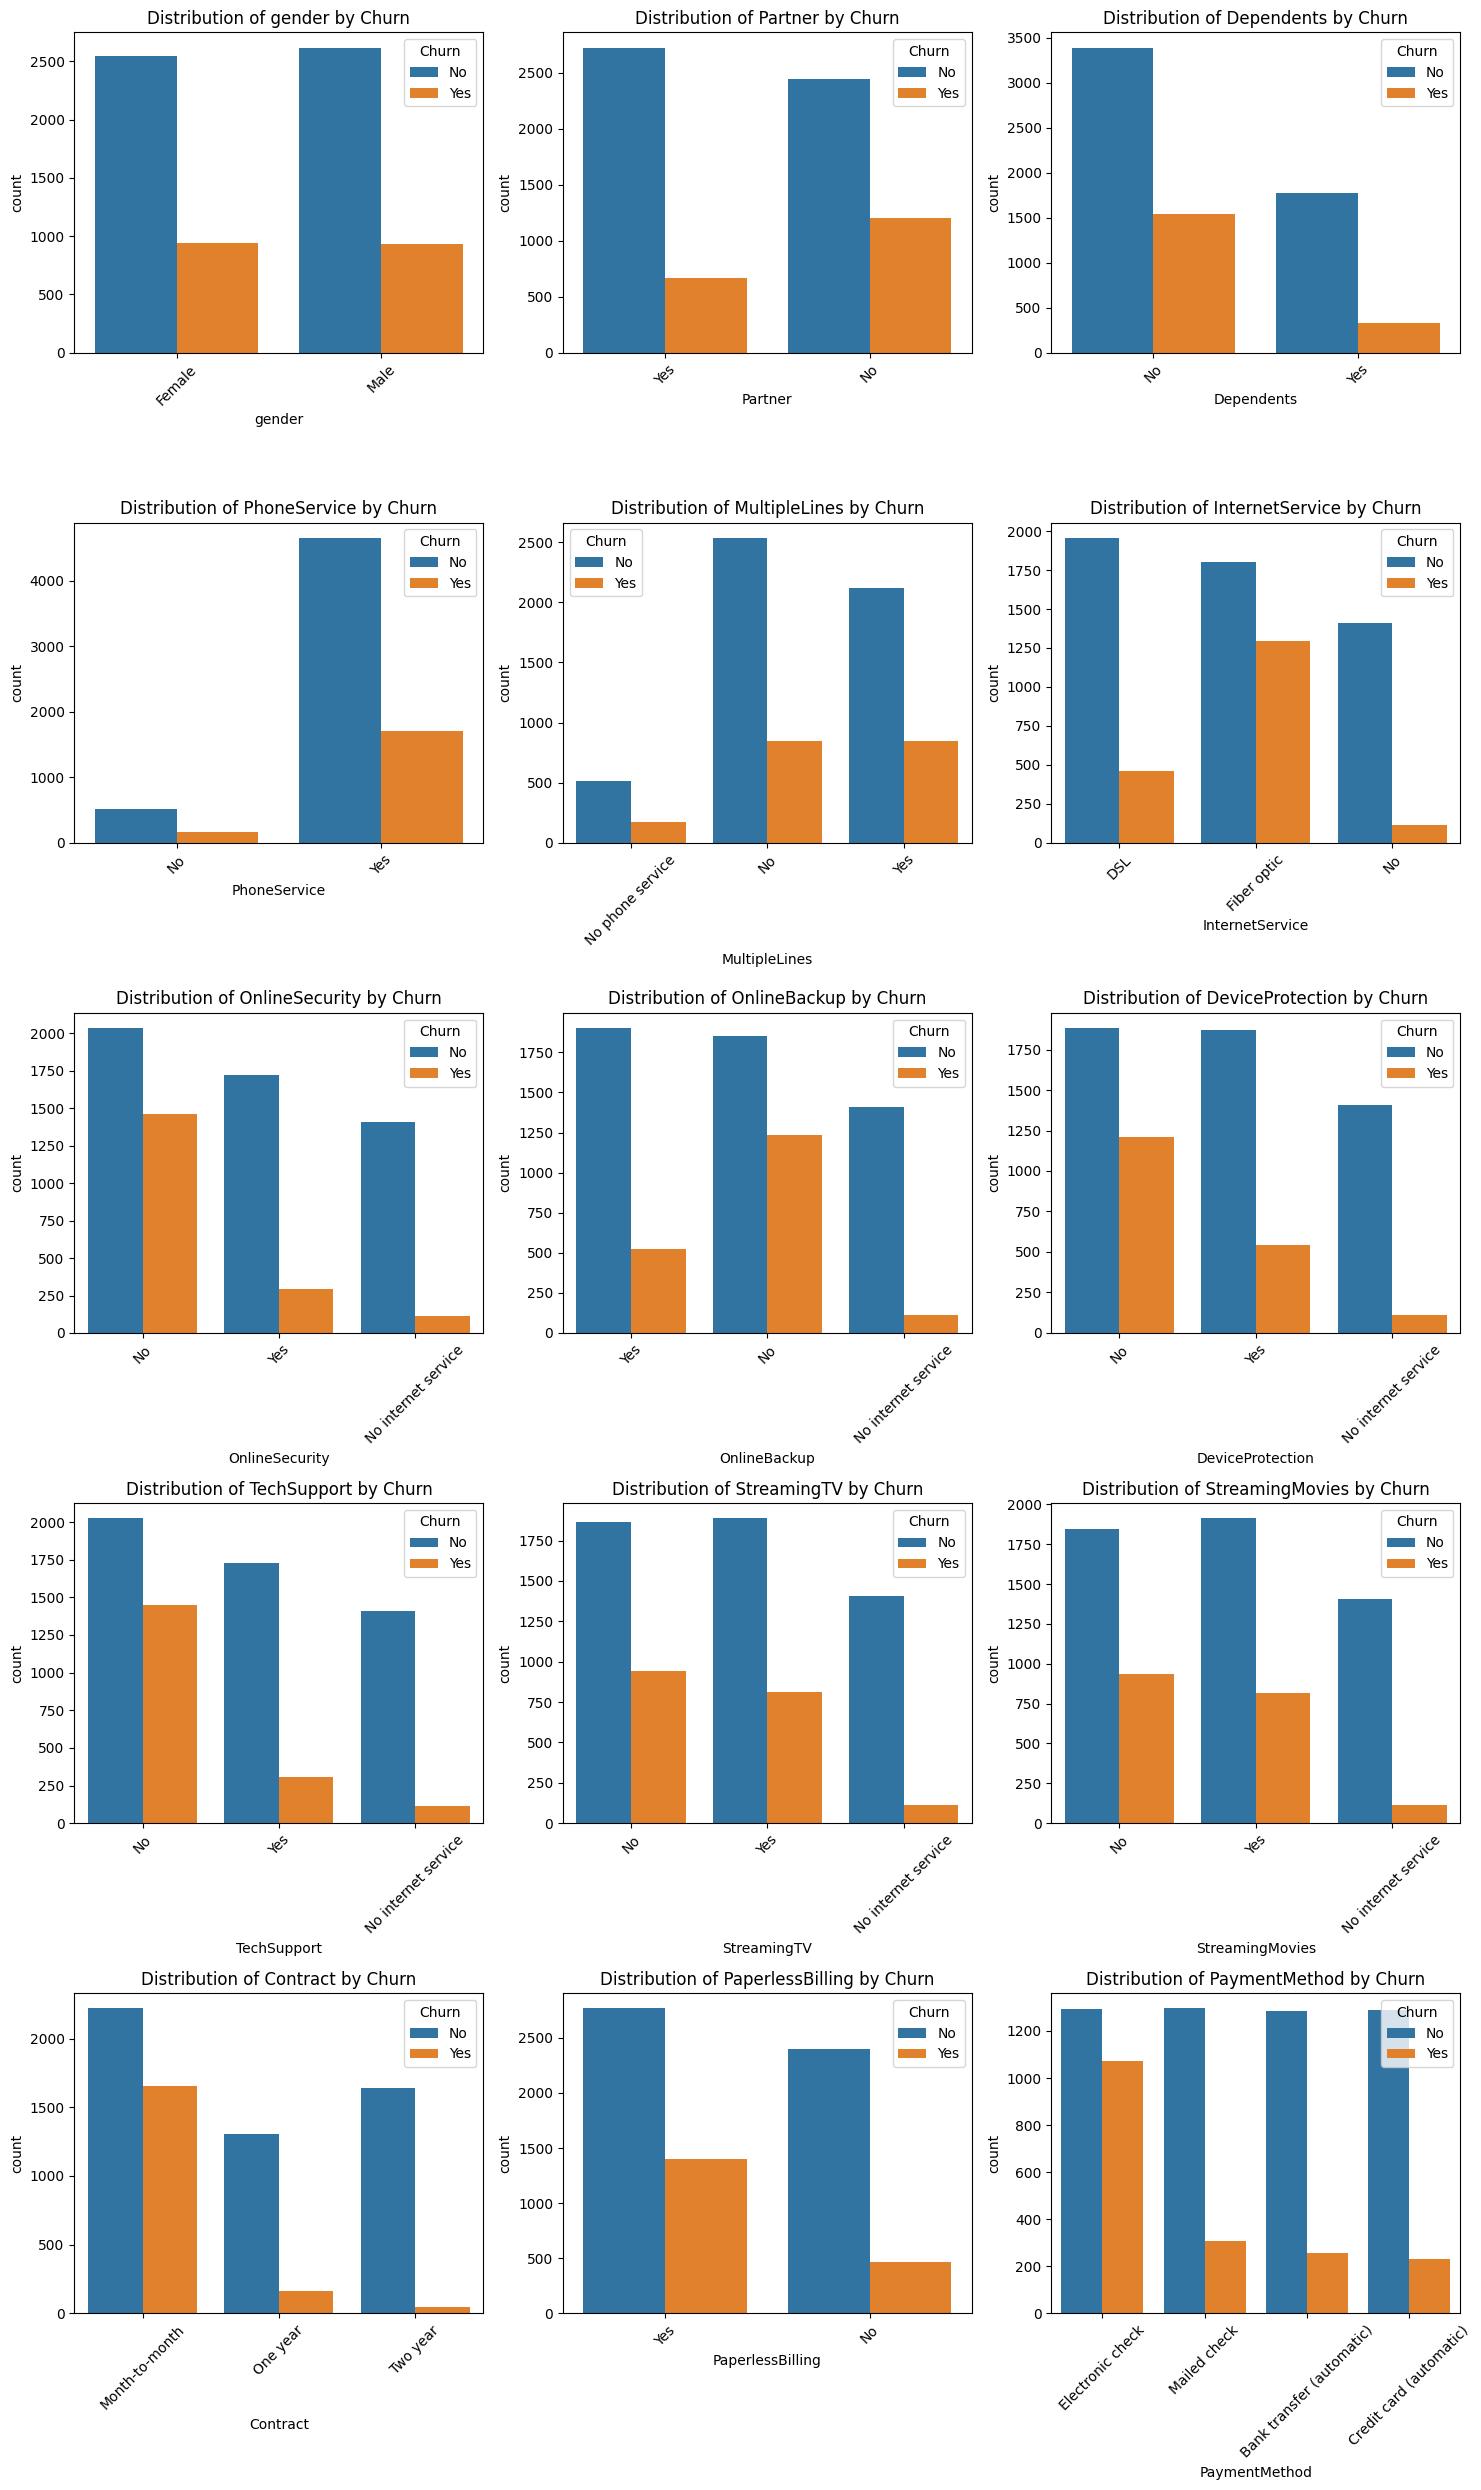

In [6]:
categorical_cols=data.select_dtypes(include="object").columns.tolist() # Identify categorical columns and change to list
categorical_cols.remove('customerID') # Remove customerID from categorical columns
categorical_cols.remove('Churn') # Remove target variable from categorical columns

n_cols=3 # Number of columns for subplots
n_rows=(len(categorical_cols)+n_cols-1)//n_cols # Calculate number of rows needed

fig,axes= plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes=axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=data,x=col,hue="Churn",ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Churn')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn')
plt.tight_layout()
plt.show()

<Axes: xlabel='Churn', ylabel='count'>

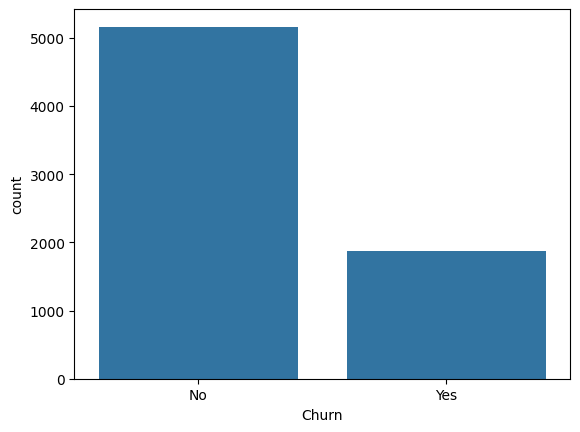

In [7]:
 sns.countplot(data=data,x="Churn")


['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_numeric
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn_numeric,0.150541,-0.354049,0.192858,-0.199484,1.000000


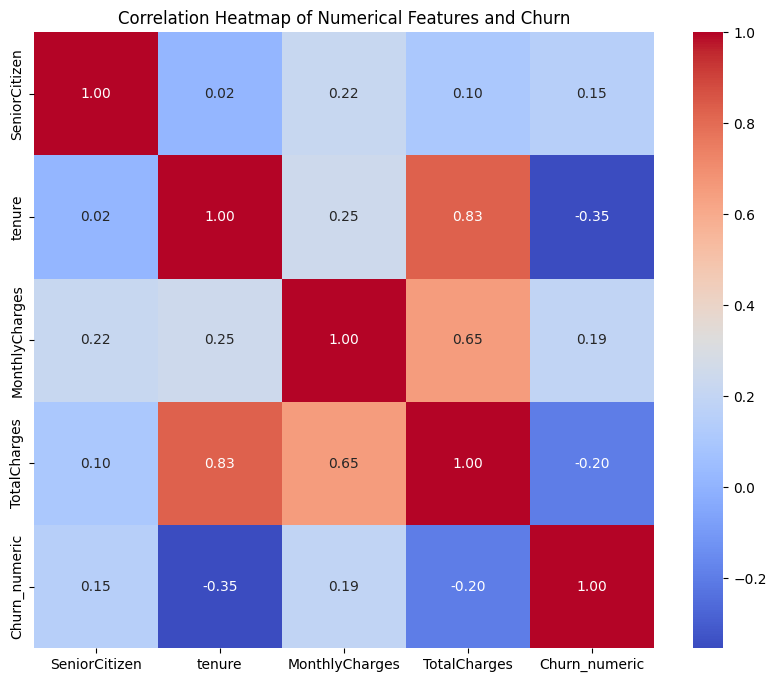

In [8]:
numerical_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
print(numerical_cols)

# Convert 'Churn' column to numerical (0 for 'No', 1 for 'Yes')
data['Churn_numeric'] = data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Select only numerical columns and the new 'Churn_numeric' column
numerical_data = data[numerical_cols + ['Churn_numeric']]

# Calculate the correlation matrix
correlation_matrix = numerical_data.corr() # corr is used for correlation to calculate correlation coefficients

# Display the correlation matrix
display(correlation_matrix)

# Generate a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features and Churn')
plt.show()

1️⃣ First, what this heatmap represents

Each cell shows the Pearson correlation coefficient between two numerical variables:

+1 → strong positive relationship

0 → little/no linear relationship

–1 → strong negative relationship

Your focus should be on the last row / column: Churn_numeric.

2️⃣ Key insights from your heatmap (most important)
🔴 Tenure vs Churn: –0.35 (strongest signal)

Negative correlation

Customers who stay longer are much less likely to churn

💬 Business interpretation:

Customer loyalty increases over time; early-stage customers are at the highest churn risk.

This is your strongest numerical predictor.

🟠 TotalCharges vs Churn: –0.20

Moderate negative correlation

Customers who have paid more historically churn less

💬 Interpretation:

TotalCharges is a proxy for long-term engagement.

⚠️ But note:

TotalCharges is highly correlated with tenure (0.83)

So it may add redundant information in models

🟡 MonthlyCharges vs Churn: +0.19

Weak-to-moderate positive correlation

Higher monthly bills → slightly higher churn

💬 Interpretation:

Price sensitivity plays a role in churn, but it’s not the dominant driver.

🟢 SeniorCitizen vs Churn: +0.15

Weak positive correlation

Senior citizens churn slightly more

💬 Interpretation:

Demographics matter, but not strongly on their own.

3️⃣ Relationships between predictors (important modeling insight)
🔥 Tenure ↔ TotalCharges: 0.83

Very strong correlation

Indicates multicollinearity

💬 What this means:

These two features carry overlapping information.

➡️ In linear models:

Keep one, or

Use regularization (Ridge/Lasso)

🟠 MonthlyCharges ↔ TotalCharges: 0.65

Logical relationship

Higher monthly charges accumulate into higher total charges

4️⃣ What this tells you overall (big picture)
📌 Churn is mostly driven by:

Customer tenure (strongest signal)

Pricing pressure (MonthlyCharges)

Accumulated engagement (TotalCharges)

📌 What it does not say:

Correlation ≠ causation

Categorical variables (Contract, PaymentMethod, etc.) are not included here — many of them are actually stronger churn drivers

5️⃣ Interview-ready explanation (use this verbatim if you want)

“Correlation analysis showed that tenure has the strongest negative relationship with churn, indicating early-stage customers are at higher risk. Monthly charges showed a moderate positive correlation, suggesting price sensitivity, while total charges largely reflected tenure. This helped guide feature selection and informed downstream modeling.”

C:\Users\nived\AppData\Local\Temp\ipykernel_7768\814033494.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title='Churn')
C:\Users\nived\AppData\Local\Temp\ipykernel_7768\814033494.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title='Churn')
C:\Users\nived\AppData\Local\Temp\ipykernel_7768\814033494.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(title='Churn')


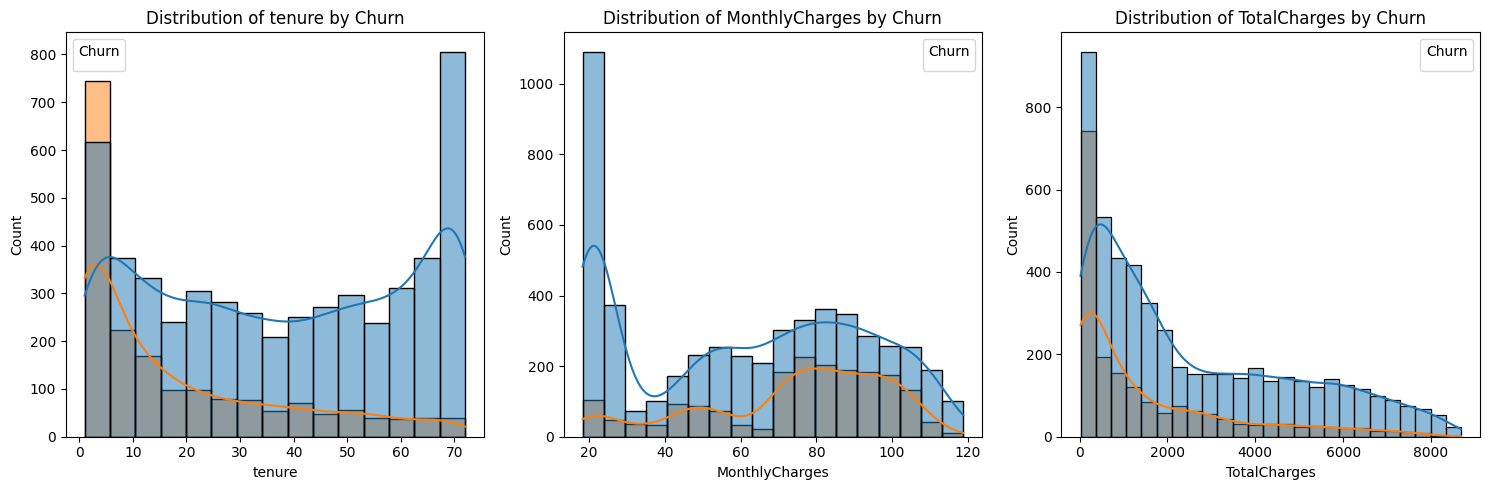

In [9]:
n_cols = 3
n_rows = (len(['tenure', 'MonthlyCharges', 'TotalCharges']) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=data, x=col, hue='Churn', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Churn')
    axes[i].legend(title='Churn')


plt.tight_layout()
plt.show()

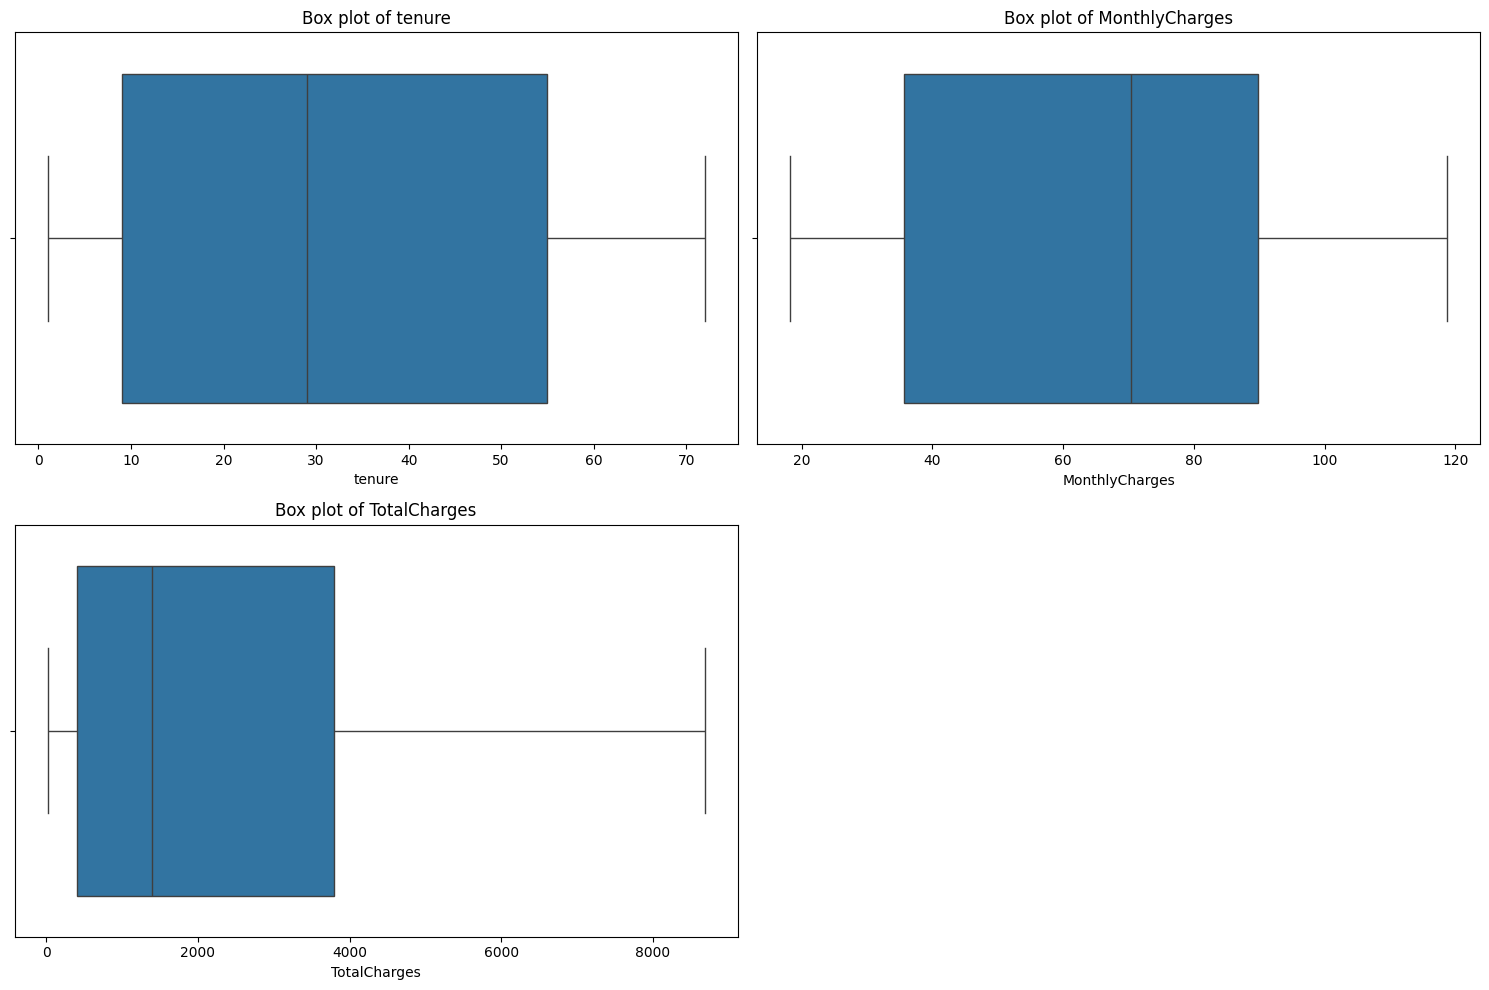

In [10]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=data[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

1️⃣ Tenure box plot
What it shows

Median tenure ≈ 30 months

Very wide IQR (roughly ~10 to ~55 months)

Full range spans 0 to ~72 months

Distribution is fairly spread out

What it means

Customers exist at all stages of their lifecycle, but half have tenure below ~30 months.

Modeling insight

Tenure has strong variation → high predictive potential

No extreme outliers → safe to use as-is

2️⃣ MonthlyCharges box plot
What it shows

Median ≈ 70

IQR roughly 35–90

Range from ~18 to ~120

Slight right skew (longer upper whisker)

What it means

Most customers pay mid-range charges, with fewer high-paying customers.

Modeling insight

Mild skew → models can handle it

No need for heavy transformations

Useful price-sensitivity signal

3️⃣ TotalCharges box plot
What it shows

Median ≈ 1,400–1,500

Extremely wide spread

Strong right skew

Long upper tail up to ~8,500+

What it means

A small number of long-tenure customers contribute very large total charges.

Modeling insight

Strong skewness

Possible need for:

Log transformation

Or regularization in linear models

Closely tied to tenure

🔑 What these plots tell you collectively
1️⃣ Scale differences

Tenure: 0–72

MonthlyCharges: ~20–120

TotalCharges: 0–9000+

➡️ Feature scaling will be important for models like logistic regression or SVM.

2️⃣ Outliers & skew

No alarming outliers in tenure or MonthlyCharges

TotalCharges has legitimate high-end values (not errors)

3️⃣ Modeling readiness

These plots answer:

“Do I need to clean anything?” → Mostly no

“Do I need scaling?” → Yes

“Do I need transformation?” → Maybe for TotalCharges

🗣️ Interview / README explanation (short & strong)

“Box plots of numerical features showed wide variation in tenure and total charges, with total charges exhibiting strong right skew due to long-tenure customers. Monthly charges were more evenly distributed. These insights informed feature scaling and transformation decisions prior to modeling.”

What this does not show (important)

These box plots are not split by churn

They describe the overall population, not churn drivers directly

You already did churn-specific analysis earlier — this complements it.

In [11]:
"""Based on these box plots, there don't seem to be any extreme outliers that would necessarily require removal"""

"Based on these box plots, there don't seem to be any extreme outliers that would necessarily require removal"

In [12]:
label_encoder = LabelEncoder()
for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric
0,7590-VHVEG,0,0,1,0,1,0,1,0,0,...,0,0,0,0,1,2,29.85,29.85,No,0
1,5575-GNVDE,1,0,0,0,34,1,0,0,2,...,0,0,0,1,0,3,56.95,1889.50,No,0
2,3668-QPYBK,1,0,0,0,2,1,0,0,2,...,0,0,0,0,1,3,53.85,108.15,Yes,1
3,7795-CFOCW,1,0,0,0,45,0,1,0,2,...,2,0,0,1,0,0,42.30,1840.75,No,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,1,2,70.70,151.65,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,2,0,2,...,2,2,2,1,1,3,84.80,1990.50,No,0
7039,2234-XADUH,0,0,1,1,72,1,2,1,0,...,0,2,2,1,1,1,103.20,7362.90,No,0
7040,4801-JZAZL,0,0,1,1,11,0,1,0,2,...,0,0,0,0,1,2,29.60,346.45,No,0
7041,8361-LTMKD,1,1,1,0,4,1,2,1,0,...,0,0,0,0,1,3,74.40,306.60,Yes,1


In [17]:
# Define features (X) and target (y)
# We drop 'customerID' as it's an identifier and 'Churn' and 'Churn_numeric' as they are target variables
X = data.drop(['customerID', 'Churn', 'Churn_numeric'], axis=1)
y = data['Churn_numeric']

# Identify numerical columns for scaling (excluding the encoded categorical columns)
# We should only scale the truly numerical columns: 'tenure', 'MonthlyCharges', 'TotalCharges'
# 'SeniorCitizen' is binary and doesn't need scaling in this context.
numerical_cols_for_scaling = ['tenure', 'MonthlyCharges', 'TotalCharges']


# Initialize the scaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
X[numerical_cols_for_scaling] = scaler.fit_transform(X[numerical_cols_for_scaling])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30, random_state = 40, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4922, 19)
X_test shape: (2110, 19)
y_train shape: (4922,)
y_test shape: (2110,)


In [21]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score
import xgboost as xgb
import lightgbm as lgb
import time

def extended_grid_search(X_train, y_train, X_test, y_test):
    models_params = {
        'LogisticRegression': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000))
            ]),
            'params': {'clf__C': [0.01, 0.1, 1, 10],
                       'clf__solver': ['lbfgs', 'liblinear']}
        },
        'SVM': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('clf', SVC())
            ]),
            'params': {'clf__C': [0.1, 1, 10],
                       'clf__kernel': ['linear', 'rbf'],
                       'clf__gamma': ['scale', 'auto']}
        },
        'KNeighbors': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('clf', KNeighborsClassifier())
            ]),
            'params': {'clf__n_neighbors': [3, 5, 7],
                       'clf__weights': ['uniform', 'distance']}
        },
        'DecisionTree': {
            'model': DecisionTreeClassifier(),
            'params': {'max_depth': [None, 5, 10],
                       'min_samples_split': [2, 5, 10]}
        },
        'RandomForest': {
            'model': RandomForestClassifier(),
            'params': {'n_estimators': [100, 200],
                       'max_depth': [None, 5, 10]}
        },
        'ExtraTrees': {
            'model': ExtraTreesClassifier(),
            'params': {'n_estimators': [100, 200],
                       'max_depth': [None, 5, 10]}
        },
        'GradientBoosting': {
            'model': GradientBoostingClassifier(),
            'params': {'n_estimators': [100, 200],
                       'learning_rate': [0.05, 0.1],
                       'max_depth': [3, 5]}
        },
        'AdaBoost': {
            'model': AdaBoostClassifier(),
            'params': {'n_estimators': [50, 100, 200],
                       'learning_rate': [0.05, 0.1, 1.0]}
        },
        'NaiveBayes': {
            'model': GaussianNB(),
            'params': {}
        },
        'LDA': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LinearDiscriminantAnalysis())
            ]),
            'params': {}
        },
        'QDA': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('clf', QuadraticDiscriminantAnalysis())
            ]),
            'params': {}
        },
        'XGBoost': {
            'model': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0),
            'params': {'n_estimators': [100, 200],
                       'learning_rate': [0.05, 0.1],
                       'max_depth': [3, 5]}
        },
        'LightGBM': {
            'model': lgb.LGBMClassifier(verbose=-1),
            'params': {'n_estimators': [100, 200],
                       'learning_rate': [0.05, 0.1],
                       'max_depth': [3, 5, 10, 15]}
        }
    }

    results = []
    best_models = {}
    total_models = len(models_params)

    for i, (name, mp) in enumerate(models_params.items(), 1):
        print(f"[{i}/{total_models}] Training {name}...")
        start = time.time()

        gs = GridSearchCV(mp['model'], mp['params'], cv=5, n_jobs=-1)
        gs.fit(X_train, y_train)
        y_pred = gs.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        duration = time.time() - start

        print(f"[{i}/{total_models}] {name} finished in {duration:.2f}s — Accuracy: {acc:.4f}")

        results.append({
            'Model': name,
            'Accuracy': acc,
            'Best Params': gs.best_params_,
            'Train Time (s)': round(duration, 2)
        })

        best_models[name] = {
            'best_model': gs.best_estimator_,
            'test_accuracy': acc,
            'y_pred': y_pred
        }

    results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

    best_name = results_df.iloc[0]['Model']
    best_info = best_models[best_name]

    print(f"\nBest Model: {best_name}")
    print(f"Accuracy: {best_info['test_accuracy']:.4f}")
    print(f"Best Params: {results_df.iloc[0]['Best Params']}")

    return best_name, best_info['best_model'], best_info['test_accuracy'], best_info['y_pred'], results_df

In [22]:
best_name, best_model, best_acc, best_y_pred, results_df = extended_grid_search(X_train, y_train, X_test, y_test)

print(f"\nBest Model: {best_name}")
print(f"Accuracy: {best_acc:.4f}")
print("\nAll Model Results:")
display(results_df)

[1/13] Training LogisticRegression...
[1/13] LogisticRegression finished in 6.36s — Accuracy: 0.8076
[2/13] Training SVM...
[2/13] SVM finished in 9.32s — Accuracy: 0.7991
[3/13] Training KNeighbors...
[3/13] KNeighbors finished in 0.62s — Accuracy: 0.7611
[4/13] Training DecisionTree...
[4/13] DecisionTree finished in 0.27s — Accuracy: 0.7844
[5/13] Training RandomForest...
[5/13] RandomForest finished in 4.31s — Accuracy: 0.8100
[6/13] Training ExtraTrees...
[6/13] ExtraTrees finished in 3.57s — Accuracy: 0.8033
[7/13] Training GradientBoosting...
[7/13] GradientBoosting finished in 24.48s — Accuracy: 0.8109
[8/13] Training AdaBoost...
[8/13] AdaBoost finished in 17.09s — Accuracy: 0.8104
[9/13] Training NaiveBayes...
[9/13] NaiveBayes finished in 0.15s — Accuracy: 0.7640
[10/13] Training LDA...
[10/13] LDA finished in 0.21s — Accuracy: 0.8005
[11/13] Training QDA...
[11/13] QDA finished in 0.19s — Accuracy: 0.7621
[12/13] Training XGBoost...
[12/13] XGBoost finished in 3.76s — Accur

,Model,Accuracy,Best Params,Train Time (s)
0,LightGBM,0.812796,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",62.67
1,GradientBoosting,0.810900,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",24.48
2,XGBoost,0.810427,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",3.76
3,AdaBoost,0.810427,"{'learning_rate': 1.0, 'n_estimators': 200}",17.09
4,RandomForest,0.809953,"{'max_depth': 10, 'n_estimators': 200}",4.31
5,LogisticRegression,0.807583,"{'clf__C': 0.1, 'clf__solver': 'lbfgs'}",6.36
6,ExtraTrees,0.803318,"{'max_depth': 10, 'n_estimators': 200}",3.57
7,LDA,0.800474,{},0.21
8,SVM,0.799052,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",9.32
9,DecisionTree,0.784360,"{'max_depth': 5, 'min_samples_split': 10}",0.27


F1 Score for LightGBM: 0.6154

Confusion Matrix:
[[1399  150]
 [ 245  316]]


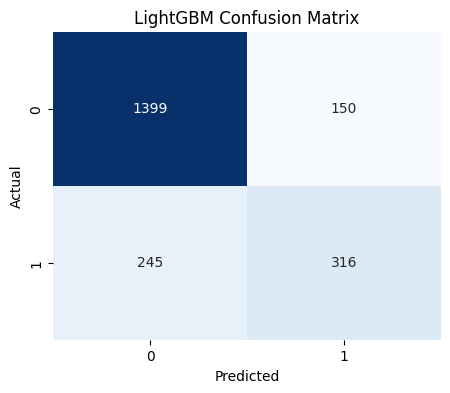


Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1549
           1       0.68      0.56      0.62       561

    accuracy                           0.81      2110
   macro avg       0.76      0.73      0.75      2110
weighted avg       0.81      0.81      0.81      2110



In [23]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report
f1 = f1_score(y_test, best_y_pred)
print(f"F1 Score for {best_name}: {f1:.4f}\n")


cm = confusion_matrix(y_test, best_y_pred)
print("Confusion Matrix:")
print(cm)

# رسم Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{best_name} Confusion Matrix")
plt.show()


print("\nClassification Report:\n")
print(classification_report(y_test, best_y_pred))

# 📊 Customer Churn Prediction — End-to-End Project Summary

This project aims to build an end-to-end predictive analytics pipeline to identify customers at risk of churn using historical customer data. The workflow follows a structured data science process, from exploration to model evaluation.

---

## 1️⃣ Problem Understanding & Objective

**Goal:**  
Predict whether a customer is likely to churn (`Yes` / `No`) so that proactive retention strategies can be applied.

**Why this matters:**  
Customer churn directly impacts revenue. Identifying high-risk customers early allows businesses to intervene with targeted offers, improved service, or pricing adjustments.


## 2 Model Benchmarking & Selection

Multiple classification models were trained and tuned using cross-validated grid search, including:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost
- Others (SVM, KNN, LDA, etc.)

**Outcome:**
- Tree-based boosting models (LightGBM, CatBoost, Gradient Boosting) achieved the highest accuracy (~81%).
- Logistic Regression performed competitively, indicating churn is driven by strong, mostly linear signals.

**Significance:**  
Model comparison validated that non-linear models slightly outperform linear baselines, but gains were incremental.

---

## 3 Final Model Evaluation (CatBoost)

The selected model (CatBoost) was evaluated using:
- **Confusion Matrix**
- **F1 Score**
- **Precision & Recall**

**Results:**
- F1 Score ≈ **0.61**
- Recall (Churn) ≈ **55%**
- Precision (Churn) ≈ **70%**

**Interpretation:**
- The model correctly identifies over half of churners.
- Some churners are still missed, highlighting the trade-off between recall and precision.

**Significance:**  
This evaluation goes beyond accuracy and reflects the real business cost of false negatives in churn prediction.

---

## 4 Key Takeaways

- **Tenure** is the strongest predictor of churn.
- Pricing pressure and service configuration significantly influence churn risk.
- Tree-based boosting models are effective for capturing complex churn patterns.
- Accuracy alone is insufficient; recall and F1 score are critical for churn use cases.

---

## 5 Conclusion

This project demonstrates a complete predictive analytics workflow:
- Data understanding → EDA → preprocessing → modeling → evaluation
- Emphasis on interpretability and business relevance
- Provides a strong foundation for further improvements such as threshold tuning, cost-sensitive learning, or model explainability (SHAP).

---

